# Synthetic Ranking Task With RuleTreeRank

This notebook builds a fully synthetic ranking problem: random document features, a hidden linear scoring function, and relevance labels induced by sorting documents inside each query.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "ruletreerank").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from RuleTree import RuleTreeRegressor
from sklearn.metrics import mean_absolute_error, ndcg_score

from ltr_utility import ModelParam
from ruletreerank import KNNRegFast, PairwiseDistanceTree, RuleTreeRank

pd.set_option("display.max_columns", 20)
RANDOM_STATE = 1
N_QUERIES = 36
DOCS_PER_QUERY = 12
N_FEATURES = 6
FEATURE_NAMES = [f"x{i + 1}" for i in range(N_FEATURES)]
LINEAR_WEIGHTS = np.array([1.5, -1.1, 0.9, 0.6, -0.4, 0.25])

## 1. Build A Synthetic Ranking Dataset

For every query we generate 12 documents with 6 random features. A hidden linear function assigns each document a score. We then sort documents within each query and convert the induced ranking into discrete relevance labels.

The model will train only from features and relevance labels; `linear_score` is kept for inspection.

In [2]:
def make_synthetic_ranking_data(random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    rows = []

    for query_id in range(N_QUERIES):
        features = rng.normal(0, 1, size=(DOCS_PER_QUERY, N_FEATURES))
        features += rng.normal(0, 0.35, size=(1, N_FEATURES))
        linear_score = features @ LINEAR_WEIGHTS + rng.normal(0, 0.08, size=DOCS_PER_QUERY)

        ranked_doc_indices = np.argsort(linear_score)[::-1]
        relevance = np.zeros(DOCS_PER_QUERY, dtype=int)
        relevance[ranked_doc_indices[:2]] = 4
        relevance[ranked_doc_indices[2:4]] = 3
        relevance[ranked_doc_indices[4:7]] = 2
        relevance[ranked_doc_indices[7:9]] = 1

        rank_position = np.empty(DOCS_PER_QUERY, dtype=int)
        rank_position[ranked_doc_indices] = np.arange(1, DOCS_PER_QUERY + 1)

        for doc_id in range(DOCS_PER_QUERY):
            rows.append({
                "query_id": query_id,
                "doc_id": doc_id,
                "linear_score": linear_score[doc_id],
                "true_rank": rank_position[doc_id],
                "relevance": relevance[doc_id],
                **{name: features[doc_id, i] for i, name in enumerate(FEATURE_NAMES)},
            })

    return pd.DataFrame(rows)


ranking_df = make_synthetic_ranking_data()
weights_table = pd.DataFrame({"feature": FEATURE_NAMES, "linear_weight": LINEAR_WEIGHTS})

query_summary = (
    ranking_df
    .groupby("query_id")
    .agg(
        n_docs=("doc_id", "size"),
        best_score=("linear_score", "max"),
        worst_score=("linear_score", "min"),
        mean_relevance=("relevance", "mean"),
    )
    .head(8)
    .round(3)
)

sample_query = (
    ranking_df[ranking_df["query_id"] == 0]
    .sort_values("true_rank")
    [["query_id", "doc_id", "linear_score", "true_rank", "relevance"] + FEATURE_NAMES]
    .round(3)
)

display(weights_table)
display(query_summary)
display(sample_query)

,feature,linear_weight
0,x1,1.50
1,x2,-1.10
2,x3,0.90
3,x4,0.60
4,x5,-0.40
5,x6,0.25


,n_docs,best_score,worst_score,mean_relevance
query_id,,,,
0,12,4.569,-3.090,1.833
1,12,2.200,-4.495,1.833
2,12,6.081,-2.407,1.833
3,12,3.184,-4.543,1.833
4,12,2.713,-3.687,1.833
5,12,0.816,-4.196,1.833
6,12,3.965,-4.057,1.833
7,12,3.352,-6.309,1.833


,query_id,doc_id,linear_score,true_rank,relevance,x1,x2,x3,x4,x5,x6
5,0,5,4.569,1,4,1.834,-0.849,-0.289,2.356,0.526,0.144
9,0,9,3.201,2,4,0.595,-0.809,1.003,0.293,-1.370,-0.833
6,0,6,1.120,3,3,-0.798,-1.385,0.256,0.423,-1.348,-1.202
7,0,7,0.285,4,3,-0.356,-0.681,-0.010,0.409,-0.085,-1.025
8,0,8,-1.290,5,2,0.310,1.154,0.410,-0.505,0.611,-1.020
1,0,1,-1.379,6,2,-0.821,0.844,0.453,0.608,-0.092,0.028
2,0,2,-1.556,7,2,-1.020,0.100,-0.393,0.912,-0.081,-0.811
0,0,0,-1.658,8,1,0.062,1.085,0.419,-0.990,0.785,-0.072
3,0,3,-1.827,9,1,-1.066,0.006,0.097,0.038,1.173,0.488
10,0,10,-2.457,10,0,-0.230,0.536,-0.893,-0.794,0.079,-0.985


## 2. Train RuleTreeRank

We hold out the last 12 queries for testing. The target is the induced relevance label. Stage 1 is a shallow rule tree; stage 2 learns local residual corrections inside each stage-1 leaf.

In [3]:
train_queries = np.arange(0, 24)
test_queries = np.arange(24, N_QUERIES)

train_df = ranking_df[ranking_df["query_id"].isin(train_queries)].reset_index(drop=True)
test_df = ranking_df[ranking_df["query_id"].isin(test_queries)].reset_index(drop=True)

X_train = train_df[FEATURE_NAMES]
y_train = train_df["relevance"].to_numpy(dtype=float)
q_train = train_df["query_id"].to_numpy()

X_test = test_df[FEATURE_NAMES]
y_test = test_df["relevance"].to_numpy(dtype=float)
q_test = test_df["query_id"].to_numpy()

rtr = RuleTreeRank(
    distance_f=ModelParam(PairwiseDistanceTree, {
        "base_regressor": ModelParam(RuleTreeRegressor, {"max_depth": 2, "random_state": RANDOM_STATE}),
        "feature_concat": False,
        "feature_diff": True,
        "feature_sq_diff": True,
        "subsample": 0.45,
        "verbose": False,
    }),
    aggregation_f=ModelParam(KNNRegFast, {"n_neighbors": 5, "n_jobs": 1}),
    base_regressor=RuleTreeRegressor(max_depth=2, random_state=RANDOM_STATE),
    dist_objective="residuals",
    verbose=False,
    n_jobs_leaf=1,
)

rtr.fit(X_train, y_train, q_train)

print(f"Train rows: {len(train_df)} across {len(train_queries)} queries")
print(f"Test rows:  {len(test_df)} across {len(test_queries)} queries")
print(f"Stage-2 leaf models: {len(rtr._leaf_dist_map)}")

Train rows: 288 across 24 queries
Test rows:  144 across 12 queries
Stage-2 leaf models: 4


## 3. Stage Decomposition And Ranking Metrics

`output="score"` is the shallow RuleTree prediction. `output="corr"` is the local residual correction. `output="full"` is their sum. We evaluate both regression error on relevance labels and NDCG@5 by query.

In [4]:
def mean_ndcg_by_query(y_true, y_score, q, k=5):
    values = []
    for query_id in np.unique(q):
        mask = q == query_id
        values.append(ndcg_score([y_true[mask]], [y_score[mask]], k=k))
    return float(np.mean(values))


stage1_score = rtr.predict(X_test, q=q_test, output="score")
stage2_correction = rtr.predict(X_test, q=q_test, output="corr")
final_score = rtr.predict(X_test, q=q_test, output="full")
test_leaf = rtr._shallow_dt.apply(X_test.to_numpy())

metrics = pd.DataFrame([
    {
        "model_output": "stage 1: shallow RuleTree",
        "MAE": mean_absolute_error(y_test, stage1_score),
        "NDCG@5": mean_ndcg_by_query(y_test, stage1_score, q_test, k=5),
    },
    {
        "model_output": "stage 1 + stage 2 correction",
        "MAE": mean_absolute_error(y_test, final_score),
        "NDCG@5": mean_ndcg_by_query(y_test, final_score, q_test, k=5),
    },
]).round(3)

prediction_table = test_df[["query_id", "doc_id", "linear_score", "true_rank", "relevance"]].copy()
prediction_table["leaf"] = test_leaf
prediction_table["stage1_score"] = stage1_score
prediction_table["stage2_correction"] = stage2_correction
prediction_table["final_score"] = final_score
prediction_table["abs_error_stage1"] = np.abs(y_test - stage1_score)
prediction_table["abs_error_final"] = np.abs(y_test - final_score)

display(metrics)
display(prediction_table.head(14).round(3))

,model_output,MAE,NDCG@5
0,stage 1: shallow RuleTree,0.993,0.780
1,stage 1 + stage 2 correction,0.944,0.831


,query_id,doc_id,linear_score,true_rank,relevance,leaf,stage1_score,stage2_correction,final_score,abs_error_stage1,abs_error_final
0,24,0,-3.010,11,0,Rlr,0.957,-0.357,0.6,0.957,0.6
1,24,1,-1.141,9,1,Rll,2.267,-0.467,1.8,1.267,0.8
2,24,2,0.479,2,4,Rrl,2.207,-0.407,1.8,1.793,2.2
3,24,3,0.279,3,3,Rrl,2.207,0.993,3.2,0.793,0.2
4,24,4,0.171,4,3,Rlr,0.957,0.243,1.2,2.043,1.8
5,24,5,-2.872,10,0,Rlr,0.957,0.243,1.2,0.957,1.2
6,24,6,3.724,1,4,Rrr,3.532,-0.132,3.4,0.468,0.6
7,24,7,0.162,5,2,Rrl,2.207,0.193,2.4,0.207,0.4
8,24,8,-9.364,12,0,Rlr,0.957,-0.557,0.4,0.957,0.4
9,24,9,-0.232,6,2,Rlr,0.957,0.843,1.8,1.043,0.2


## 4. Stage-1 Leaves And Stage-2 Local Models

The first stage partitions the training documents into leaves. The second stage fits one local k-NN correction model for each leaf, using the learned pairwise distance model as its metric.

In [5]:
X_train_np = X_train.to_numpy()
train_leaf = rtr._shallow_dt.apply(X_train_np)
train_stage1 = rtr._shallow_dt.predict(X_train_np)

train_diag = pd.DataFrame({
    "leaf": train_leaf,
    "relevance": y_train,
    "stage1_score": train_stage1,
    "residual_after_stage1": y_train - train_stage1,
})

leaf_residuals = (
    train_diag
    .groupby("leaf")
    .agg(
        n_train=("relevance", "size"),
        relevance_mean=("relevance", "mean"),
        stage1_mean=("stage1_score", "mean"),
        residual_mean=("residual_after_stage1", "mean"),
        residual_std=("residual_after_stage1", "std"),
    )
)

stage2_models = pd.DataFrame([
    {
        "leaf": leaf,
        "knn_rows": int(agg._fit_X.shape[0]),
        "n_neighbors": int(agg.n_neighbors),
        "learned_distance": agg.custom_metric_func is not None,
    }
    for leaf, agg in rtr._leaf_dist_map.items()
]).set_index("leaf")

leaf_table = leaf_residuals.join(stage2_models).sort_values("n_train", ascending=False).round(3)
display(leaf_table)

,n_train,relevance_mean,stage1_mean,residual_mean,residual_std,knn_rows,n_neighbors,learned_distance
leaf,,,,,,,,
Rlr,138,0.957,0.957,-0.0,1.024,138,5,True
Rrl,58,2.207,2.207,0.0,1.151,58,5,True
Rrr,47,3.532,3.532,0.0,0.747,47,5,True
Rll,45,2.267,2.267,0.0,1.214,45,5,True


## 5. Visual Check On A Held-Out Query

The next chart reads one test query in the true linear-score order. The final score should be closer to the induced relevance ordering than the shallow stage-1 score alone.

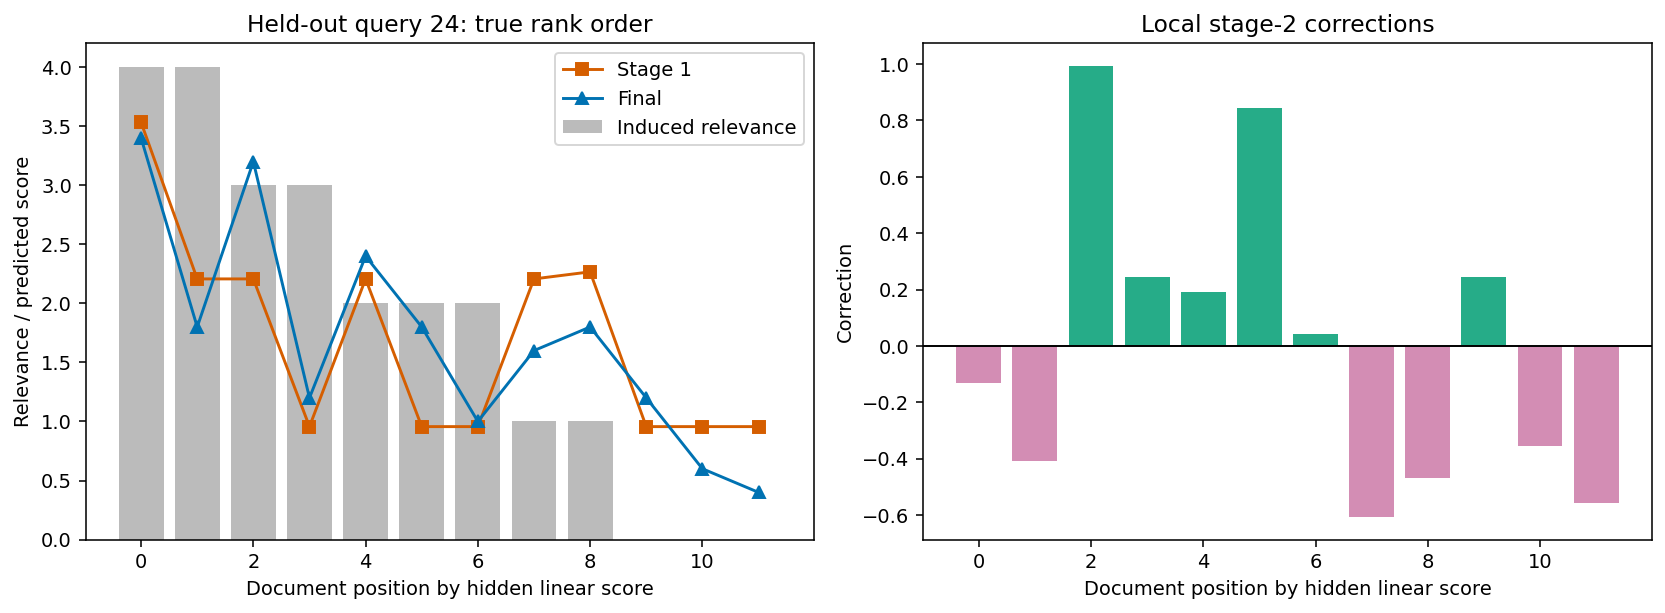

In [6]:
plot_query = int(test_queries[0])
query_view = (
    prediction_table[prediction_table["query_id"] == plot_query]
    .sort_values("true_rank")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(len(query_view))
axes[0].bar(x, query_view["relevance"], color="#BBBBBB", label="Induced relevance")
axes[0].plot(x, query_view["stage1_score"], marker="s", linewidth=1.5, label="Stage 1", color="#D55E00")
axes[0].plot(x, query_view["final_score"], marker="^", linewidth=1.5, label="Final", color="#0072B2")
axes[0].set_title(f"Held-out query {plot_query}: true rank order")
axes[0].set_xlabel("Document position by hidden linear score")
axes[0].set_ylabel("Relevance / predicted score")
axes[0].legend()

correction_colors = np.where(query_view["stage2_correction"] >= 0, "#009E73", "#CC79A7")
axes[1].bar(x, query_view["stage2_correction"], color=correction_colors, alpha=0.85)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Local stage-2 corrections")
axes[1].set_xlabel("Document position by hidden linear score")
axes[1].set_ylabel("Correction")

plt.tight_layout()
plt.show()